# Baseline Scorecard Model

Starting with logistic regression as the interpretable baseline. The idea is to have something simple to compare the tree models against.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "credit_risk_model_table.csv")


In [2]:
target = "default_next_month"
drop_columns = ["customer_id", "statement_month", target]
X = df.drop(columns=drop_columns)
y = df[target]

categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [column for column in X.columns if column not in categorical]

preprocess = ColumnTransformer([
    ("numeric", StandardScaler(), numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model.fit(X_train, y_train)
predicted_pd = model.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, predicted_pd):.3f}")
print(f"Brier score: {brier_score_loss(y_test, predicted_pd):.4f}")


AUC: 0.795
Brier score: 0.1729


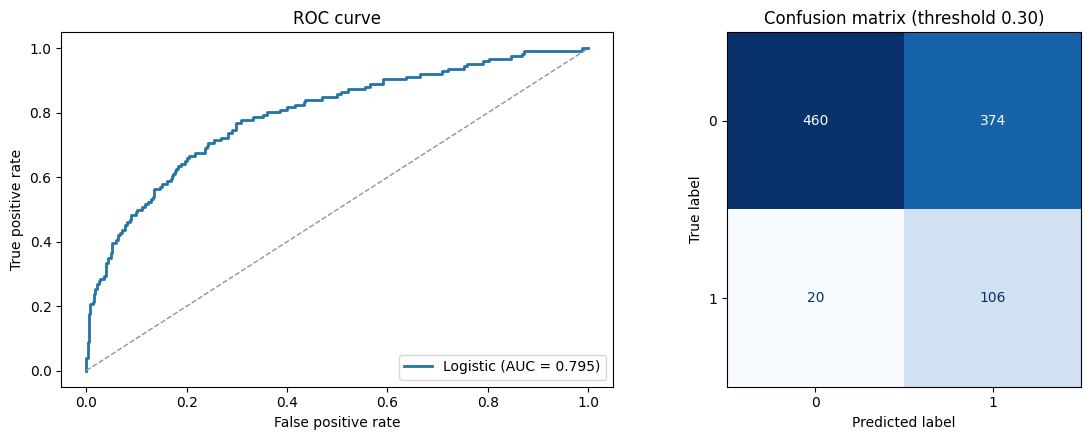

In [3]:
from sklearn.metrics import roc_curve, auc as auc_score

fpr, tpr, _ = roc_curve(y_test, predicted_pd)
roc_auc = auc_score(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, color="#2474a6", linewidth=2, label=f"Logistic (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#8996a3", linewidth=1)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    y_test, (predicted_pd >= 0.30).astype(int),
    ax=axes[1], cmap="Blues", colorbar=False,
)
axes[1].set_title("Confusion matrix (threshold 0.30)")

plt.tight_layout()
plt.show()


In [4]:
risk_bands = pd.DataFrame({"predicted_pd": predicted_pd, "observed": y_test.to_numpy()})
risk_bands["risk_band"] = pd.qcut(
    risk_bands["predicted_pd"],
    q=5,
    labels=["A", "B", "C", "D", "E"],
)
band_summary = risk_bands.groupby("risk_band", observed=True).agg(
    customers=("observed", "size"),
    average_predicted_pd=("predicted_pd", "mean"),
    observed_default_rate=("observed", "mean"),
)
band_summary


,customers,average_predicted_pd,observed_default_rate
risk_band,,,
A,192,0.069873,0.031250
B,192,0.169330,0.046875
C,192,0.306374,0.062500
D,192,0.518698,0.145833
E,192,0.795117,0.369792


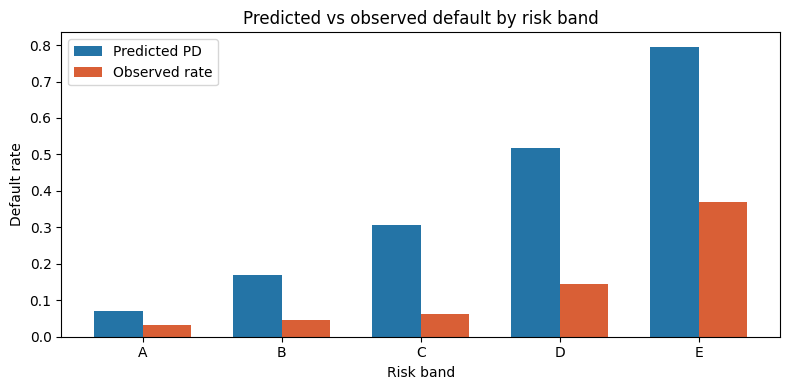

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(band_summary))
width = 0.35
ax.bar([i - width/2 for i in x], band_summary["average_predicted_pd"], width, label="Predicted PD", color="#2474a6")
ax.bar([i + width/2 for i in x], band_summary["observed_default_rate"], width, label="Observed rate", color="#d95f36")
ax.set_xticks(x)
ax.set_xticklabels(band_summary.index)
ax.set_xlabel("Risk band")
ax.set_ylabel("Default rate")
ax.set_title("Predicted vs observed default by risk band")
ax.legend()
plt.tight_layout()
plt.show()
